Plot Figure 3c
--

In [1]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.patches as patches

from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm

from DATA.MetUM_variables import VARDIC
from config import IUMFIGDIR
from CP4.utils.make_colorbar import MidpointNormalize
from utils.meteo_constants import rho, g
from IUM.config import zmax
from IUM.treat_data.compute_theta_ctrl import load_theta_ctrl
from IUM.treat_data.compute_theta_pert import load_theta_pert
from IUM.compute_twb.make_rolling_mean_ctrl import load_rolling_mean_ctrl
from IUM.compute_twb.make_rolling_mean_pert import load_rolling_mean_pert
from IUM.compute_twb.compute_theta_wb_ctrl import load_theta_wb_ctrl
from IUM.compute_twb.compute_theta_wb_pert import load_theta_wb_pert
from IUM.read_data.read_data import *
from IUM.plots.p_config import clim_vars_ano, labelsep

Done
Done
Done
Done
Done
Done
Done
Done


In [3]:
var = 'twb'
res = 0.5
value = 0.3
value_pert = 1.
length = 50
u = 4.
env = 'stable'
date = '10010101'
time = 15
window = 3
windstep = 10

In [4]:
p_srfc_udry = load_raw_ctrl_surf_var(res=res, value=value, u=u, env=env, date=date, variable='p_srfc')
p_srfc_uwet = load_raw_ctrl_surf_var(res=res, value=value_pert, u=u, env=env, date=date, variable='p_srfc')
u_uwet = load_raw_ctrl_plvls_var(res=res, value=value_pert, u=u, env=env, date=date, variable='u_pl')
u_uwet = u_uwet.rolling(T1HR_MN=window, center=True).mean()
w_uwet = load_proc_pl_var_ctrl(res=res, value=value_pert, u=u, env=env, date=date)
w_uwet = w_uwet.rolling(T1HR_MN=window, center=True).mean()

srfc_theta_wb_udry = load_theta_wb_ctrl(res=res, value=value, u=u, env=env, variable='theta_wb') - 273.15
srfc_theta_wb_uwet = load_theta_wb_ctrl(res=res, value=value_pert, u=u, env=env, variable='theta_wb') - 273.15

theta_wb_uwet = load_raw_ctrl_plvls_var(res=res, value=value_pert, u=u, env=env, date=date, variable='theta_wb_pl') - 273.15

pblh_udry = load_raw_ctrl_surf_var(res=res, value=value, u=u, env=env, date=date, variable='PBLh')
pblh_udry = pblh_udry.rolling(T1HR_MN=window, center=True).mean()
pblh_uwet = load_raw_ctrl_surf_var(res=res, value=value_pert, u=u, env=env, date=date, variable='PBLh')
pblh_uwet = pblh_uwet.rolling(T1HR_MN=window, center=True).mean()

lons = u_uwet.longitude_uv.values
lats = u_uwet.latitude_uv.values

p_srfc_udry = p_srfc_udry.isel(T1HR_MN=time-1)
p_srfc_uwet = p_srfc_uwet.isel(T1HR_MN=time-1)

u_uwet = u_uwet.isel(T1HR_MN=time-1)  # .interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])
w_uwet = w_uwet.isel(T1HR_MN=time-1)  # .interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])

srfc_theta_wb_udry = srfc_theta_wb_udry.isel(T1HR_MN=time-1)
srfc_theta_wb_uwet = srfc_theta_wb_uwet.isel(T1HR_MN=time-1)

pblh_udry = pblh_udry.isel(T1HR_MN=time-1)
pblh_uwet = pblh_uwet.isel(T1HR_MN=time-1)

theta_wb_uwet = theta_wb_uwet.isel(T1HR_MN=time-1)

pblh_udry = (p_srfc_udry - rho*g*pblh_udry) / 100  # m -> hPa
pblh_uwet = (p_srfc_uwet - rho*g*pblh_uwet) / 100  # m -> hPa

assert u_uwet.T1HR_MN == srfc_theta_wb_uwet.T1HR_MN == pblh_uwet.T1HR_MN == theta_wb_uwet.T1HR_MN

In [6]:
p_srfc_pert = load_raw_pert_surf_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable='p_srfc')
p_srfc_pert = p_srfc_pert.rolling(T1HR_MN=window, center=True).mean()

u_pert = load_raw_pert_plvls_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable='u_pl')
u_pert = u_pert.rolling(T1HR_MN=window, center=True).mean()
w_pert = load_proc_pl_var_pert(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date)
w_pert = w_pert.rolling(T1HR_MN=window, center=True).mean()

srfc_theta_wb_pert = load_theta_wb_pert(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, variable='theta_wb') - 273.15
theta_wb_pert = load_raw_pert_plvls_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable='theta_wb_pl') - 273.15

pblh_pert = load_raw_pert_surf_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable='PBLh')
pblh_pert = pblh_pert.rolling(T1HR_MN=window, center=True).mean()

p_srfc_pert = p_srfc_pert.isel(T1HR_MN=time-1)
u_pert = u_pert.isel(T1HR_MN=time-1)  # .interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])
w_pert = w_pert.isel(T1HR_MN=time-1)  # .interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])

srfc_theta_wb_pert = srfc_theta_wb_pert.isel(T1HR_MN=time-1)

pblh_pert = pblh_pert.isel(T1HR_MN=time-1)

theta_wb_pert = theta_wb_pert.isel(T1HR_MN=time-1)

pblh_pert = (p_srfc_pert - rho*g*pblh_pert) / 100  # m -> hPa

assert p_srfc_pert.T1HR_MN == u_pert.T1HR_MN == w_pert.T1HR_MN == srfc_theta_wb_pert.T1HR_MN == pblh_pert.T1HR_MN == theta_wb_pert.T1HR_MN

In [7]:
#~ Get patch values

xs = np.arange(res, 400.+res, res)
ys = xs
xc = (xs[-1] - xs[0]) / 2 + res / 2
yc = (ys[-1] - ys[0]) / 2 + res / 2

xsm, ysm = np.meshgrid(xs, ys)

r = length / 2

distloc = ( ((xsm - xc) * (xsm - xc)) + ((ysm - yc) * (ysm - yc)) )**.5
disc_mask = np.broadcast_to(distloc <= r, srfc_theta_wb_pert.shape)   # True in disc
disc_mask_3d = np.broadcast_to(distloc <= r, theta_wb_pert.shape)   # True in disc
disc_mask_3d_raw = np.broadcast_to(distloc <= r, w_pert.shape)   # True in disc

srfc_theta_wb_pert_wet = srfc_theta_wb_pert.where(disc_mask)
u_pert_wet = u_pert.where(disc_mask_3d_raw)
w_pert_wet = w_pert.where(disc_mask_3d_raw)

In [8]:
#~ Compute anomalies

u_uwet = u_uwet.interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])
w_uwet = w_uwet.interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])
u_pert = u_pert.interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])
w_pert = w_pert.interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])

u_ano = u_pert - u_uwet
w_ano = w_pert - w_uwet

srfc_var_ano = srfc_theta_wb_pert - srfc_theta_wb_uwet
var_ano = theta_wb_pert - theta_wb_uwet

u_ano_var = u_ano.var(dim=['latitude_uv', 'longitude_uv'])  # .var
w_ano_var = w_ano.var(dim=['latitude_uv', 'longitude_uv'])  # .var

u_ano_var = np.concatenate([[np.nan], u_ano_var])
w_ano_var = np.concatenate([[np.nan], w_ano_var])

arrow_length_ano = 2.

In [9]:
#~ Sub-sample data -> averaging domain

lat_mid = (lats[-1] - lats[0]) / 2 + lats[0]
lon_mid = (lons[-1] - lons[0]) / 2 + lons[0]
lat_step = 10  # length / 2
lon_step = 10  # length / 2

p_srfc_udry_lon = p_srfc_udry.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t') / 100  # Pa -> hPa
p_srfc_uwet_lon = p_srfc_uwet.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t') / 100  # Pa -> hPa
p_srfc_pert_lon = p_srfc_pert.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t') / 100  # Pa -> hPa

u_ano_lon = u_ano.sel(latitude_uv=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_uv')
w_ano_lon = w_ano.sel(latitude_uv=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_uv') * 4  # for scaling -> arrowlength

In [10]:
srfc_var_ano_lon = np.array([srfc_var_ano.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')])

pblh_udry_lon = pblh_udry.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')
pblh_uwet_lon = pblh_uwet.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')
pblh_pert_lon = pblh_pert.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')

srfc_var_udry_lon = srfc_theta_wb_udry.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')
srfc_var_uwet_lon = srfc_theta_wb_uwet.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')
srfc_var_pert_lon = srfc_theta_wb_pert.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')

var_ano_lon = var_ano.sel(latitude_t=slice(lat_mid-lat_step, lat_mid+lat_step)).mean(dim='latitude_t')

var_ano_2plot_lon = np.concatenate([srfc_var_ano_lon, var_ano_lon])
var_ano_2plot_lon_mean = var_ano_2plot_lon.mean(axis=1)

p_srfc_lon_max = max(p_srfc_uwet_lon.max().values, p_srfc_pert_lon.max().values)

levels = u_ano.PLEVS.values

zs_lon = 1 - (levels - levels.min()) / (p_srfc_lon_max - levels.min())
zs_lon = np.concatenate((np.array([0]), zs_lon), axis=0)

pblh_udry_lon = 1 - (pblh_udry_lon - levels.min()) / (p_srfc_lon_max - levels.min())
pblh_uwet_lon = 1 - (pblh_uwet_lon - levels.min()) / (p_srfc_lon_max - levels.min())
pblh_pert_lon = 1 - (pblh_pert_lon - levels.min()) / (p_srfc_lon_max - levels.min())

ytcks = zs_lon
ytlbs = [str(int(l)) for l in levels]
ytlbs = ['' if yt not in ytlbs[::2] else yt for yt in ytlbs]
ytlbs = [''] + ytlbs  # [str(int(l)) for l in levels]

var_ano_lon_min = var_ano_2plot_lon.min()
var_ano_lon_max = var_ano_2plot_lon.max()
w_ano_lon_min = w_ano_lon.min().values / 5
w_ano_lon_max = w_ano_lon.max().values / 5
u_ano_min = u_ano_lon.min().values
u_ano_max = u_ano_lon.max().values

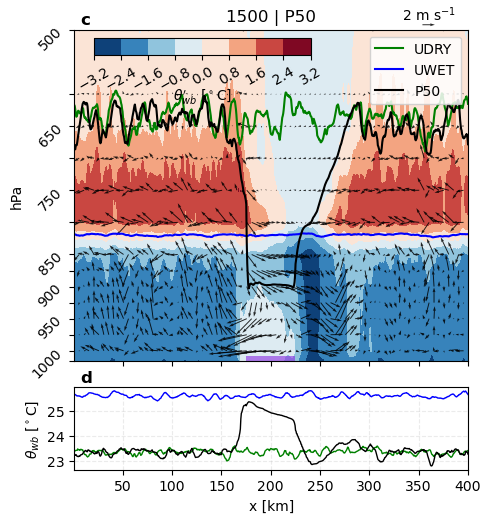

In [16]:
#~ Plot


clim_var = clim_vars_ano[var]
clim_min = round(var_ano_lon_min, 1)  #, var_ano_lat_min)
clim_max = 2.4 #round(var_ano_lon_max, 1)  #, var_ano_lat_max)

hpatch = Line2D([0,1], [0, 0], lw=1., color='orange')

cmap = plt.get_cmap('RdBu_r')

norm = MidpointNormalize(vmin=clim_min, vmax=clim_max, midpoint=0)

xrect = int(lon_mid - length / 2)
yrect = 0
wrect = length
hrect = ytcks[1] / 2


fig, ax = plt.subplots(nrows=2, ncols=1, gridspec_kw={'height_ratios': [4, 1]})

plt.subplots_adjust(bottom=0.125, top=0.925, left=0.1, right=0.975, wspace=0.1, hspace=0.125)

p = ax[0].contourf(lons, zs_lon, var_ano_2plot_lon, norm=norm, cmap=cmap)
pw_lon = ax[0].quiver(lons[::windstep], zs_lon[1:], u_ano_lon, w_ano_lon, alpha=0.85)
ax[0].plot(lons, pblh_udry_lon, lw=1.5, color='g', label='UDRY')
ax[0].plot(lons, pblh_uwet_lon, lw=1.5, color='b', label='UWET')
ax[0].plot(lons, pblh_pert_lon, lw=1.5, color='k', label='P%i'%length)

ax[0].quiverkey(pw_lon, 0.9, 1.015, arrow_length_ano, label='%i m s$^{-1}$'%arrow_length_ano, labelsep=labelsep)

rect = patches.Rectangle((xrect, yrect), wrect, hrect, facecolor='blueviolet', alpha=0.6)
ax[0].add_patch(rect)

ax[0].text(0.015, 1.015, "c", weight='bold', fontsize=12, transform=ax[0].transAxes)

ax[1].plot(lons, srfc_var_udry_lon, lw=1., color='g')
ax[1].plot(lons, srfc_var_uwet_lon, lw=1., color='b')
ax[1].plot(lons, srfc_var_pert_lon, lw=1., color='k')

ax[1].text(0.015, 1.05, "d", weight='bold', fontsize=12, transform=ax[1].transAxes)

ax[0].set_xlim(lons[0], lons[-1])
ax[0].set_xticklabels([])
ax[0].set_ylabel('hPa')
ax[0].set_yticks(ytcks)
ax[0].set_yticklabels(ytlbs, rotation=45)
ax[0].set_ylim(0., zs_lon[13])
ax[0].set_title('%i00 | P%i'%(time, length))
ax[1].set_xlim(lons[0], lons[-1])
ax[1].set_xlabel('x [km]')
ax[1].set_ylabel("$\\theta_{wb}$ [$^\circ$C]")
ax[1].grid(True, ls='--', alpha=0.25)

ax[0].legend(ncol=1, loc='upper right', frameon=True, framealpha=0.85)

cbaxes = ax[0].inset_axes([0.05, 0.925, 0.55, 0.05])
cb = plt.colorbar(p, norm=norm, cmap=cmap, cax=cbaxes, extend='both', orientation='horizontal')  #, label="$\\theta_{wb}'$ [$^\circ$C]")
cb.set_label(label="$\\theta_{wb}'$ [$^\circ$C]", labelpad=-5)
cb.ax.tick_params(labelrotation=30)

fig.set_size_inches(4.5, 5.5)